# TSI

`TSIGenerator` creates diverse series by combining randomized trend, seasonality, and irregular components. Each generated series samples a fresh configuration, so one call can produce a varied synthetic pool.

The component-based construction is informed by Bahrpeyma et al. (2021), [A Methodology for Validating Diversity in Synthetic Time Series Generation](https://doi.org/10.1016/j.mex.2021.101459). SynForecast's component families, sampling distributions, and stability guards are its own design choices rather than a reproduction of the paper's generator.

In [ ]:
import matplotlib.pyplot as plt
import polars as pl

from synforecast.generators import TSIGenerator

## Generate a diverse pool

Lengths are fixed here to make the series easy to compare. The remaining defaults randomize the trend shape, seasonal harmonics, irregular process, magnitude, and additive or multiplicative composition.

In [ ]:
generator = TSIGenerator(
    engine="polars",
    min_length=256,
    max_length=256,
    freq="h",
    seed=42,
)
tsi_df = generator.generate(n_series=4)

summary = tsi_df.group_by("unique_id").agg(
    pl.len().alias("length"),
    pl.col("y").mean().alias("mean"),
    pl.col("y").std().alias("std"),
)
summary

unique_id,length,mean,std
cat,u32,f64,f64
"""3""",256,9.960003,16.37748
"""0""",256,-1.564618,0.675566
"""1""",256,-4.0516,2.524986
"""2""",256,2.734903,1.325484


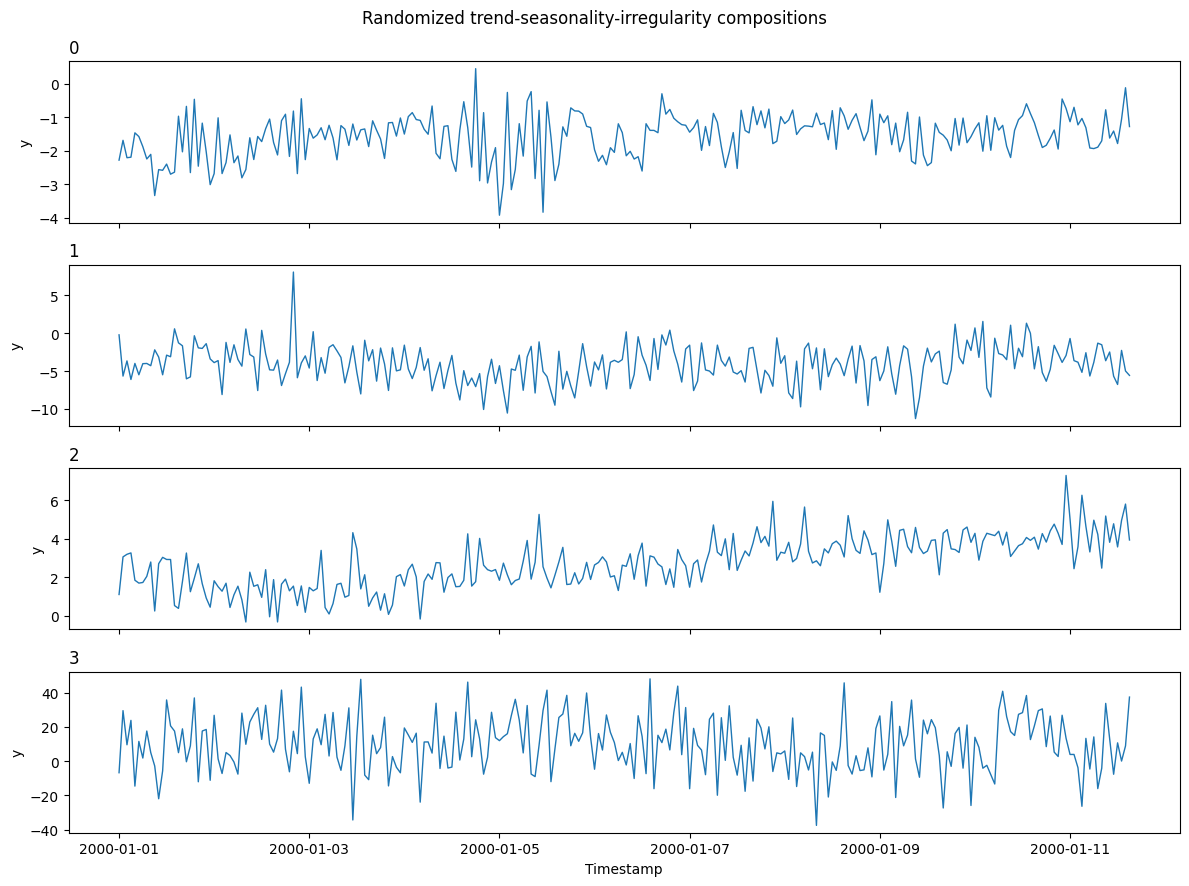

In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
for ax, uid in zip(axes, tsi_df["unique_id"].unique(maintain_order=True), strict=True):
    series = tsi_df.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"], series["y"], linewidth=1)
    ax.set_title(str(uid), loc="left")
    ax.set_ylabel("y")
axes[-1].set_xlabel("Timestamp")
fig.suptitle("Randomized trend-seasonality-irregularity compositions")
plt.tight_layout()
plt.show()

## Constrain the component pool

Every component family can be narrowed when a dataset needs a more specific inductive bias. This example limits the pool to linear or damped trends, one or two seasonal components, and Gaussian or AR(1) irregularity.

In [ ]:
controlled = TSIGenerator(
    engine="polars",
    min_length=168,
    max_length=168,
    freq="h",
    trend_types=["linear", "damped"],
    n_seasonal_range=(1, 2),
    seasonal_periods=[12.0, 24.0, 168.0],
    irregular_types=["gaussian", "ar1"],
    seed=7,
)
controlled.generate(n_series=2).head()

unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,11.837247
"""0""",2000-01-01 01:00:00,17.178323
"""0""",2000-01-01 02:00:00,12.562518
"""0""",2000-01-01 03:00:00,17.547732
"""0""",2000-01-01 04:00:00,15.332925


::: {.callout-tip}
## Related generators

- [TCM](tcm) — random causal-graph dynamics; [KernelSynth](kernel_synth) — Gaussian-process kernel compositions.
- [Balanced pool](../../capabilities/balanced_pool) — interpretable single-mechanism generators for benchmarking.

Full parameters are in the [generator reference](https://github.com/Nixtla/synforecast/blob/main/GENERATORS.md).
:::